<a href="https://colab.research.google.com/github/sudipta-on/Qiskit_v2_HandsOn/blob/main/VQE_Fermi_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="
font-family:'Times New Roman', Times, serif;
padding:24px;
border-radius:14px;
background: linear-gradient(135deg,#f5f7ff,#e8f0ff);
border:2px solid #cfd9ff;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
">

<p style="
font-size:40px;
text-align:center;
font-weight:bold;
color:#b30000;
margin-bottom:4px;
letter-spacing:0.5px;">
⚛️ Variational Quantum Eigensolver (VQE)
</p>

<p style="
font-size:22px;
text-align:center;
color:#1F618D;
font-weight:bold;
margin-top:4px;">
📖 Tutorial Part II: Fermi–Hubbard Model
</p>

<p style="
font-size:18px;
text-align:center;
color:#333;
margin-top:6px;">
From Simple Spin Systems to Strongly Correlated Fermions
</p>

<hr style="border:1px solid #c9d6ff; margin:16px 0;">

<p style="
font-size:19px;
color:#0a3d91;
text-align:left;">
📘 <b>Course:</b> Quantum Mechanics and Quantum Computation (CD61001)
</p>

<p style="
font-size:16px;
color:#444;
text-align:left;"><a href="https://colab.research.google.com/drive/1WfXFFNiqm4sw7rMbNoU_79UMypd8kXtU?usp=sharing">
🔗 <b>Previous Session:</b> Ising Model (Spin Systems) </a>
</p>

<p style="
font-size:17px;
color:#444;
text-align:right;
margin-top:10px;">
🚀 Hybrid Quantum-Classical Approach for Many-Body Ground States
</p>

</div>

<div style="
background:linear-gradient(90deg,#c5dcf5,#8fbce6);
padding:12px 20px;
border-radius:8px;
margin-top:12px;
margin-bottom:12px;
border:1px solid #6fa8dc;">

<h2 style="color:#0b3c6f; margin:0; font-family:'Times New Roman', serif;">
💻 Chapter 1 | VQE for the Fermi–Hubbard Model
</h2>

</div>

<a id="setup"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">Installation and Imports
</h2>
Run the below code to install required packages

In [1]:
!pip install qiskit qiskit_aer qiskit_algorithms qiskit_ibm_runtime pylatexenc qiskit_nature -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [2]:
import numpy as np
from qiskit import transpile
from qiskit_nature.second_q.hamiltonians import FermiHubbardModel
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.hamiltonians.lattices import LineLattice, BoundaryCondition
# from qiskit_nature.second_q.hamiltonians.lattices import (LineLattice, SquareLattice, HyperCubicLattice, BoundaryCondition)
from qiskit_nature.second_q.problems import LatticeModelProblem


from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SPSA, COBYLA, L_BFGS_B, SLSQP
from qiskit_aer.primitives import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
from qiskit.circuit.library import TwoLocal, efficient_su2, n_local, real_amplitudes

from qiskit_algorithms.utils import algorithm_globals

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD, UCC

import matplotlib.pyplot as plt

<a id="hubbard-hamiltonian"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">
1.1 Defining the Fermi–Hubbard Hamiltonian
</h2>

<div style="font-family:'Times New Roman', Times, serif; line-height:1.6;">

<p style="font-size:17px;">
The <b>Fermi–Hubbard model</b> is a fundamental model in condensed matter physics used to describe
<strong>interacting electrons on a lattice</strong>. It captures key phenomena such as
<b>conductivity, magnetism, and strongly correlated systems</b>.
</p>

<p style="font-size:17px;">
The Hamiltonian for a lattice system is given by:
</p>

$$ {\Large
H = -t \sum_{\langle i,j \rangle, \sigma}
(c_{i\sigma}^\dagger c_{j\sigma} + h.c.)
+ U \sum_i n_{i\uparrow} n_{i\downarrow}
+ v \sum_{i,\sigma} n_{i\sigma}
\Large }$$

<p style="font-size:17px;">
where
</p>

<ul style="font-size:17px;">
<li><b>$t \, \rightarrow$</b>  hopping strength (electron movement between sites)</li>
<li><b>$U\, \rightarrow$</b>  on-site interaction (electron repulsion)</li>
<li><b>$v\, \rightarrow$</b>  chemical potential (controls particle number)</li>
<li><b>$c^\dagger, c \, \rightarrow$</b>  creation and annihilation operators</li>
<li><b>$n \, \rightarrow$</b>  number operator (electron occupation)</li>
</ul>

<p style="font-size:17px;">
In quantum computing, this fermionic Hamiltonian is mapped to
<b>Pauli operators</b> (via transformations like Jordan–Wigner) so it can be
evaluated using algorithms such as <b>VQE</b>.
</p>

</div>


========== MODEL ==========
Lattice Type       : line
Sites              : 2
Particles (up,down): (1, 1)
t (hopping)        : -1.0
U (interaction)    : 4.0

========== HAMILTONIAN ==========
SparsePauliOp(['IIII', 'IYZY', 'IXZX', 'YZYI', 'XZXI', 'IIZI', 'IIIZ', 'IIZZ', 'ZIII', 'IZII', 'ZZII'],
              coeffs=[ 2. +0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -1. +0.j, -1. +0.j,
  1. +0.j, -1. +0.j, -1. +0.j,  1. +0.j])

Qubits : 4
Terms  : 11


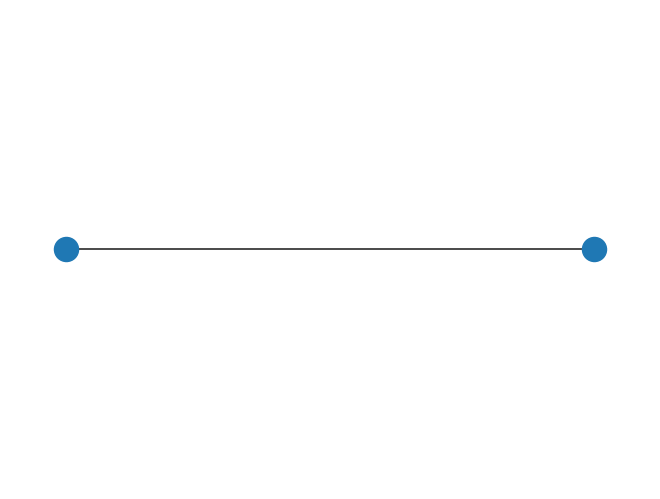

In [3]:
# HAMILTONIAN CONFIGURATION

lattice_type = "line"          # "line", "square"

num_sites = 2                 # number of lattice sites (line case)

num_particles = (1, 1)       # (spin-up, spin-down)

boundary = BoundaryCondition.OPEN   # OPEN or PERIODIC

t = -1.0     # hopping strength
U = 4.0      # interaction strength
v = 0.0      # onsite potential


# line lattice
lattice = LineLattice(num_nodes=num_sites, boundary_condition=boundary)

# Square lattice
# rows, cols = 2, 2
# lattice = SquareLattice(rows=rows, cols=cols, boundary_condition=boundary)

# Creates fermionic Hamiltonian:
# H = hopping (t) + interaction (U) + onsite (v)
model = FermiHubbardModel(
    lattice.uniform_parameters(
        uniform_interaction=t,
        uniform_onsite_potential=v,
    ),
    onsite_interaction=U,
)

problem = LatticeModelProblem(model)

# Fermionic operator (creation/annihilation form)
fermionic_op = problem.second_q_ops()[0]

# Jordan-Wigner Transformation: fermions to qubits mapping
mapper = JordanWignerMapper()

qubit_op = mapper.map(fermionic_op)

# Convert to Pauli operator
Hamiltonian = SparsePauliOp.from_list(qubit_op.to_list())


print("\n========== MODEL ==========")
print(f"Lattice Type       : {lattice_type}")
print(f"Sites              : {num_sites}")
print(f"Particles (up,down): {num_particles}")
print(f"t (hopping)        : {t}")
print(f"U (interaction)    : {U}")

print("\n========== HAMILTONIAN ==========")
print(Hamiltonian)

print("\nQubits :", Hamiltonian.num_qubits)   # = 2 × sites
print("Terms  :", len(Hamiltonian.paulis))  # number of Pauli terms

# Shows connectivity of sites
lattice.draw()

<a id="ising-ansatz"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.2 Designing the Ansatz
</h2>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<p style="font-size:17px;">
Qiskit provides several built-in <b>parameterized quantum circuits</b> (ansätze)
used in variational algorithms like VQE. These circuits generate trial quantum
states whose parameters are optimized to minimize the energy of a Hamiltonian.
</p>

<ul style="font-size:17px;">
<li><b>EfficientSU2</b> – Hardware-efficient circuit using rotation gates
(<b>RY, RZ</b>) and entangling CNOT layers.</li>

<li><b>RealAmplitudes</b> – Uses only <b>RY rotations</b> with entanglement;
commonly used for optimization problems.</li>

<li><b>TwoLocal</b> – A flexible ansatz where users can choose rotation gates,
entanglement pattern, and repetitions.</li>

</div>

In [4]:
# Defining Ansatz

# ansatz = n_local(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 2)
ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "ry", "rx"], reps = 3, entanglement = 'circular')
# ansatz = TwoLocal(Hamiltonian.num_qubits,rotation_blocks=['ry'],entanglement_blocks='cx',entanglement='linear',reps=2)

backend = AerSimulator()
ansatz = transpile(ansatz, backend)

num_params = ansatz.num_parameters
print("Ansatz parameters:", num_params)
print("Qubits:", ansatz.num_qubits)
print(ansatz.decompose())

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


Ansatz parameters: 48
Qubits: 4
global phase: (-0.5)*θ[0] - 0.5*θ[1] - 0.5*θ[2] - 0.5*θ[3] - 0.5*θ[12] - 0.5*θ[13] - 0.5*θ[14] - 0.5*θ[15] - 0.5*θ[24] - 0.5*θ[25] - 0.5*θ[26] - 0.5*θ[27] - 0.5*θ[36] - 0.5*θ[37] - 0.5*θ[38] - 0.5*θ[39]
     ┌────────────┐┌─────────┐┌─────────────┐┌───────────┐ ┌───┐     »
q_0: ┤ U(π/2,0,π) ├┤ P(θ[0]) ├┤ R(θ[4],π/2) ├┤ R(θ[8],0) ├─┤ X ├──■──»
     ├────────────┤├─────────┤├─────────────┤├───────────┤ └─┬─┘┌─┴─┐»
q_1: ┤ U(π/2,0,π) ├┤ P(θ[1]) ├┤ R(θ[5],π/2) ├┤ R(θ[9],0) ├───┼──┤ X ├»
     ├────────────┤├─────────┤├─────────────┤├───────────┴┐  │  └───┘»
q_2: ┤ U(π/2,0,π) ├┤ P(θ[2]) ├┤ R(θ[6],π/2) ├┤ R(θ[10],0) ├──┼───────»
     ├────────────┤├─────────┤├─────────────┤├────────────┤  │       »
q_3: ┤ U(π/2,0,π) ├┤ P(θ[3]) ├┤ R(θ[7],π/2) ├┤ R(θ[11],0) ├──■───────»
     └────────────┘└─────────┘└─────────────┘└────────────┘          »
«     ┌────────────┐ ┌──────────┐ ┌──────────────┐ ┌────────────┐ »
«q_0: ┤ U(π/2,0,π) ├─┤ P(θ[12]) ├─┤ R(θ[16],π/2) ├─┤ R(θ[2

<a id="ising-statevector"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.3 VQE with AerEstimator (NoiseFree)

</h2>

In [5]:
algorithm_globals.random_seed = 75

counts = []
values = []
params = []
# Running the VQE simulation
def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)
        params.append(parameters)

# Defining Estimator
estimator = Estimator(options={'run_options':{'shots':4096}})

# Run VQE
vqe = VQE(estimator,
           ansatz,
           optimizer=COBYLA(maxiter=300),
           callback=store_intermediate_result
          )
result = vqe.compute_minimum_eigenvalue(Hamiltonian)

print(result)
# print(result.cost_function_evals)
# print(result.optimizer_time)

exact_solver = NumPyMinimumEigensolver()
exact_result = exact_solver.compute_minimum_eigenvalue(Hamiltonian)

gs_energy = exact_result.eigenvalue.real

{   'aux_operators_evaluated': None,
    'cost_function_evals': 300,
    'eigenvalue': np.float64(-0.8376367619681636),
    'optimal_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7868d7747e90>,
    'optimal_parameters': {   ParameterVectorElement(θ[15]): np.float64(6.010577556876085),
                              ParameterVectorElement(θ[9]): np.float64(-5.051047610838291),
                              ParameterVectorElement(θ[6]): np.float64(6.765939642190919),
                              ParameterVectorElement(θ[17]): np.float64(4.535763716532152),
                              ParameterVectorElement(θ[8]): np.float64(4.107266486076323),
                              ParameterVectorElement(θ[27]): np.float64(4.718580715617601),
                              ParameterVectorElement(θ[13]): np.float64(-4.440673657135265),
                              ParameterVectorElement(θ[29]): np.float64(-5.143385368121565),
                              ParameterVectorEle

Exact Ground State Energy           : -1.000000
VQE on Aer simulator (without noise): -0.837636761968164
Delta from reference energy value   : 0.1623632380
Time Taken                          : 3.56 sec


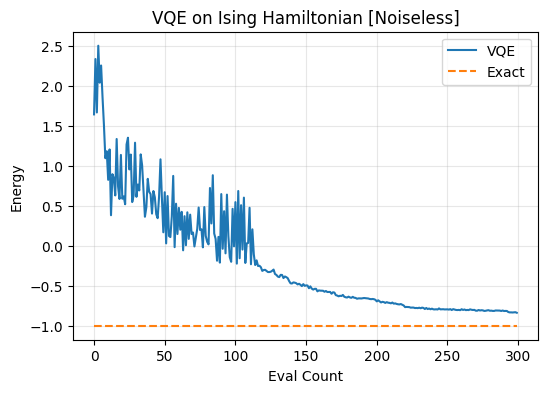

In [6]:
print(f"Exact Ground State Energy           : {gs_energy:.6f}")
print(f"VQE on Aer simulator (without noise): {result.eigenvalue.real:.15f}")
print(f"Delta from reference energy value   : {(result.eigenvalue.real - gs_energy):.10f}")
print(f"Time Taken                          : {result.optimizer_time:.2f} sec")

iterations = range(len(values))

plt.figure(figsize=(6,4))

plt.plot(iterations, np.array(values) , label='VQE')
plt.plot(iterations, (gs_energy) * np.ones(len(values)), '--', label='Exact')

plt.xlabel("Eval Count")
plt.ylabel('Energy')
plt.title('VQE on Ising Hamiltonian [Noiseless]')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# result.optimal_circuit.draw("mpl")

<a id="ising-aer"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.4 VQE with Aer Custom Noise Model
</h2>


In [7]:
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

seed = 75
algorithm_globals.random_seed = seed

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.001, 1), ["rx", "rz"]
)
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.005, 2), ["cx"]
)

print(noise_model)
noisy_estimator = AerEstimator(
    options={
            "backend_options": {"noise_model": noise_model},
            "run_options": {"shots": 4096}
            },
)

# re-start callback variables
counts = []
values = []

vqe.estimator = noisy_estimator
vqe.optimizer = COBYLA(maxiter=300)

result_noise = vqe.compute_minimum_eigenvalue(operator=Hamiltonian)

NoiseModel:
  Basis gates: ['cx', 'id', 'rx', 'rz', 'sx']
  Instructions with noise: ['rz', 'cx', 'rx']
  All-qubits errors: ['rx', 'rz', 'cx']



Exact Ground State Energy: -1.000000
VQE on Aer simulator (without noise): -0.601275836784214
Delta from reference energy value is 0.3987241632
Time Taken: 3.56 sec


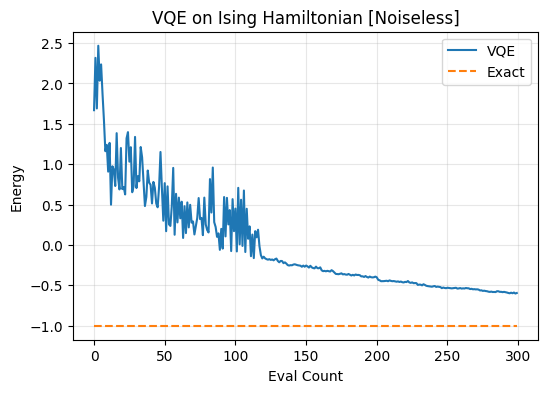

In [8]:
print(f"\nExact Ground State Energy: {gs_energy:.6f}")

print(f"VQE on Aer simulator (without noise): {result_noise.eigenvalue.real:.15f}")
print(f"Delta from reference energy value is {(result_noise.eigenvalue.real - gs_energy):.10f}")
print(f"Time Taken: {result.optimizer_time:.2f} sec")

iterations = range(len(values))

plt.figure(figsize=(6,4))

plt.plot(iterations, np.array(values) , label='VQE')
plt.plot(iterations, (gs_energy) * np.ones(len(values)), '--', label='Exact')

plt.xlabel("Eval Count")
plt.ylabel('Energy')
plt.title('VQE on Ising Hamiltonian [Noiseless]')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# result.optimal_circuit.draw("mpl")

<a id="ising-fake"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.5 VQE on Fake Backend
</h2>

<p style="font-family:'Times New Roman', Times, serif; font-size:16px;">
In Qiskit, a <b>FakeBackend</b> is a software model that mimics the behavior of a real IBM Quantum device. Instead of running a circuit on actual quantum hardware, the
simulation is performed locally on your computer using <b>Qiskit Aer</b>, while still incorporating the hardware properties and noise characteristics of a real device.
</p>

<p style="font-family:'Times New Roman', Times, serif; font-size:16px;">
This allows researchers and students to test and analyze quantum circuits under
<b>realistic hardware conditions</b> without needing access to an actual quantum computer.
</p>

In [9]:
from qiskit_ibm_runtime.fake_provider import (FakeManilaV2, FakeLimaV2, FakeJakartaV2, FakeAthensV2, FakeBelemV2,
                                                FakeBogotaV2, FakeCasablancaV2, FakeNairobiV2, FakePerth, FakeOslo)

# Fake backend
backend_choice = "Manila"

backend_map = {
    "Manila": FakeManilaV2,
    "Lima": FakeLimaV2,
    "Jakarta": FakeJakartaV2,
    "Athens": FakeAthensV2,
    "Belem": FakeBelemV2,
    "Bogota": FakeBogotaV2,
    "Casablanca": FakeCasablancaV2,
    "Nairobi": FakeNairobiV2,
    "Perth": FakePerth,
    "Oslo": FakeOslo
}

fake_backend = backend_map[backend_choice]()

# Noise model
noise_model = NoiseModel.from_backend(fake_backend)
print(f"Backend Used: {backend_choice}")
print(noise_model)

# Estimator
fake_estimator = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model,
            "coupling_map": fake_backend.coupling_map,
            "basis_gates": fake_backend.operation_names,
        },
        "run_options": {"shots": 4096}}
)

ansatz = transpile(ansatz, fake_backend)

# re-start callback variables
counts = []
values = []

vqe.estimator = fake_estimator
vqe.optimizer = COBYLA(maxiter=1000)

result_fake = vqe.compute_minimum_eigenvalue(operator=Hamiltonian)

Backend Used: Manila
NoiseModel:
  Basis gates: ['cx', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Instructions with noise: ['x', 'measure', 'sx', 'reset', 'cx', 'id']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('reset', (0,)), ('reset', (1,)), ('reset', (2,)), ('reset', (3,)), ('reset', (4,)), ('cx', (0, 1)), ('cx', (1, 0)), ('cx', (1, 2)), ('cx', (2, 1)), ('cx', (2, 3)), ('cx', (3, 2)), ('cx', (3, 4)), ('cx', (4, 3)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]



Exact Ground State Energy: -1.000000
VQE on Aer simulator (without noise): -0.715361413502522
Delta from reference energy value is 0.2846385865
Time Taken: 74.41 sec


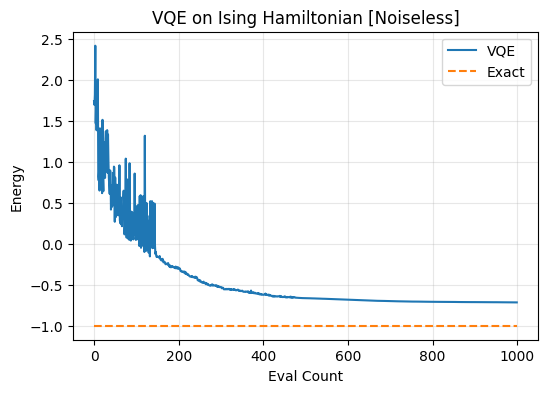

In [10]:
print(f"\nExact Ground State Energy: {gs_energy:.6f}")

print(f"VQE on Aer simulator (without noise): {result_fake.eigenvalue.real:.15f}")
print(f"Delta from reference energy value is {(result_fake.eigenvalue.real - gs_energy):.10f}")
print(f"Time Taken: {result_fake.optimizer_time:.2f} sec")

iterations = range(len(values))

plt.figure(figsize=(6,4))

plt.plot(iterations, np.array(values) , label='VQE')
plt.plot(iterations, (gs_energy) * np.ones(len(values)), '--', label='Exact')

plt.xlabel("Eval Count")
plt.ylabel('Energy')
plt.title('VQE on Ising Hamiltonian [Noiseless]')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# result.optimal_circuit.draw("mpl")

In [12]:
import pkg_resources
import platform

print("🔹 Installed Qiskit-related Packages\n")

for pkg in sorted(pkg_resources.working_set, key=lambda x: x.project_name.lower()):
    if "qiskit" in pkg.project_name.lower():
        print(f"{pkg.project_name} == {pkg.version}")

print("\n🔹 System Info")
print("Python:", platform.python_version())
print("OS:", platform.system(), platform.release())

🔹 Installed Qiskit-related Packages

qiskit == 2.3.1
qiskit-aer == 0.17.2
qiskit-algorithms == 0.4.0
qiskit-ibm-runtime == 0.46.1
qiskit-nature == 0.7.2

🔹 System Info
Python: 3.12.13
OS: Linux 6.6.113+
